In [1]:
import torch
import os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import torchvision.transforms as transforms
from PIL import Image
from utils import CorruptionDataset, UNet

In [9]:
# load trained model
def load_model(model_path, device='cuda'):
    model = UNet(in_channels=3, out_channels=3).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    return model

# run inference and visualize results
def run_inference_and_visualize(model_path, dataset_dir, output_dir, device='cuda'):
    # Transform for image resizing and tensor conversion
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),  
    ])

    # Load the trained model
    model = load_model(model_path, device)

    dataset = CorruptionDataset(root_dir=dataset_dir, transform=transform)
    loader = DataLoader(dataset, batch_size=1, shuffle=True)  # batch_size=1 for single image

    # Get a sample batch and move to device
    x, y = next(iter(loader))  # x: input (corrupted), y: target (clean)
    x = x.to(device)
    y = y.to(device)  # Ensure target is also on the same device

    # Run model on corrupted image
    with torch.no_grad():
        preds = model(x)  # preds will be on the same device as x (cuda)
    
    # Move everything to CPU before saving or plotting (if you want to visualize on CPU)
    x = x.cpu()
    preds = preds.cpu()
    y = y.cpu()

    # Save and visualize
    save_image(torch.cat([x, preds, y], dim=0), os.path.join(output_dir, 'cleaning_results.png'), nrow=1)

    x, preds, y = x.permute(0, 2, 3, 1).numpy(), preds.permute(0, 2, 3, 1).numpy(), y.permute(0, 2, 3, 1).numpy()

    # Plot original, predicted, and target images
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(x[0])  # Original corrupted image
    axes[0].set_title('Original Corrupted Image')
    axes[1].imshow(preds[0])  # Predicted cleaned image
    axes[1].set_title('Predicted Cleaned Image')
    axes[2].imshow(y[0])  # Target clean image
    axes[2].set_title('Target Clean Image')

    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07610384..1.0156502].


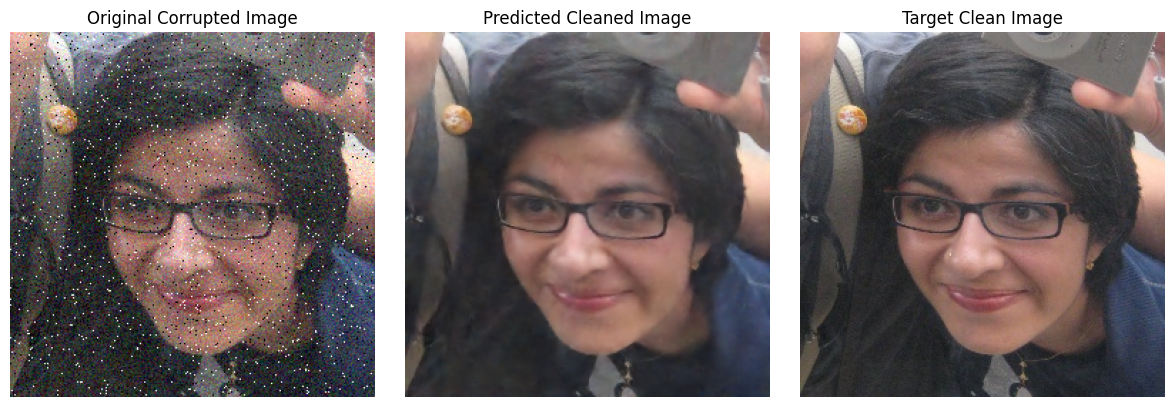

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00052702427..0.9871882].


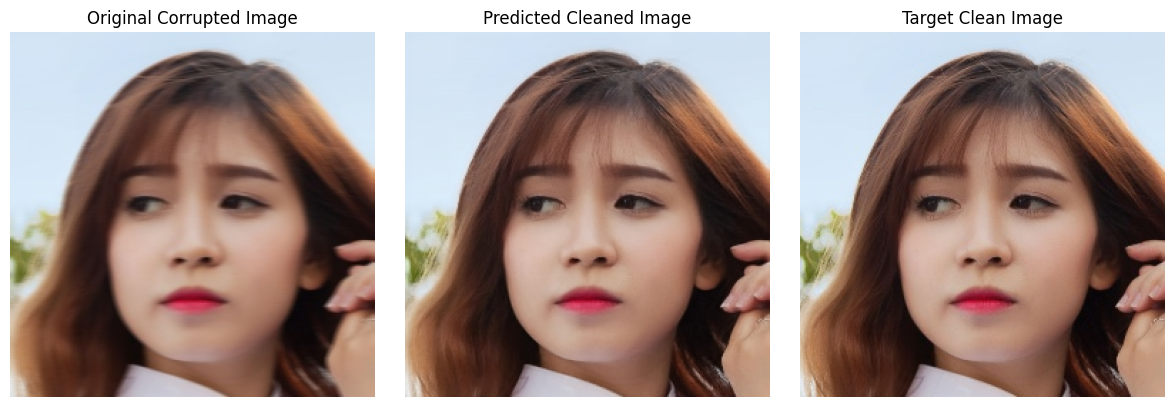

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06840891..1.0312409].


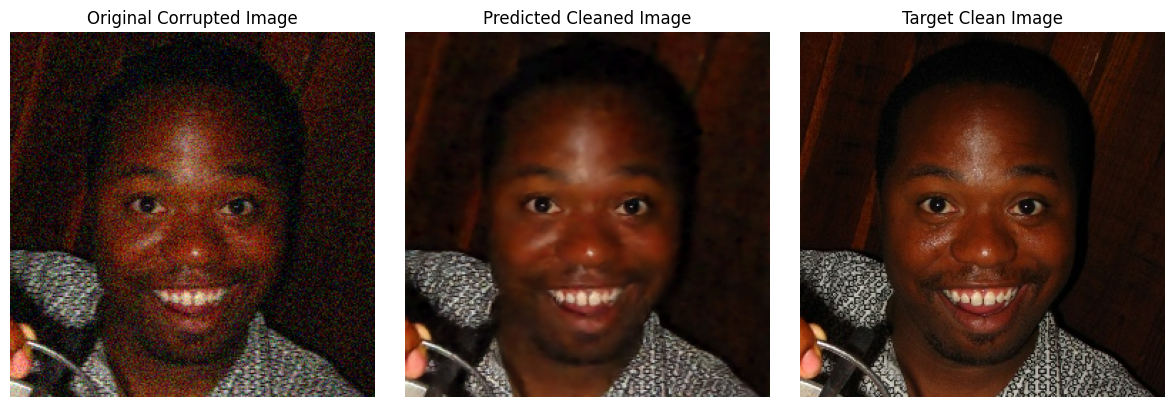

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.043911606..1.008692].


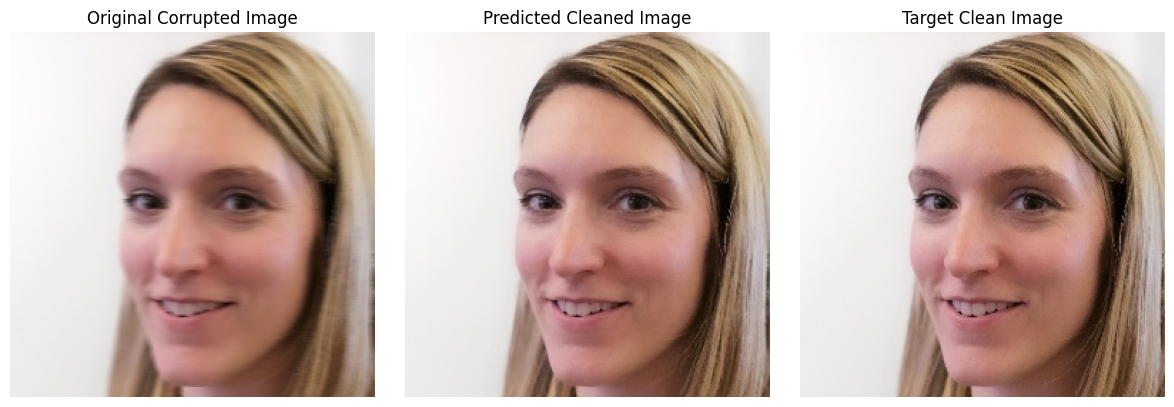

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00063861907..1.0634336].


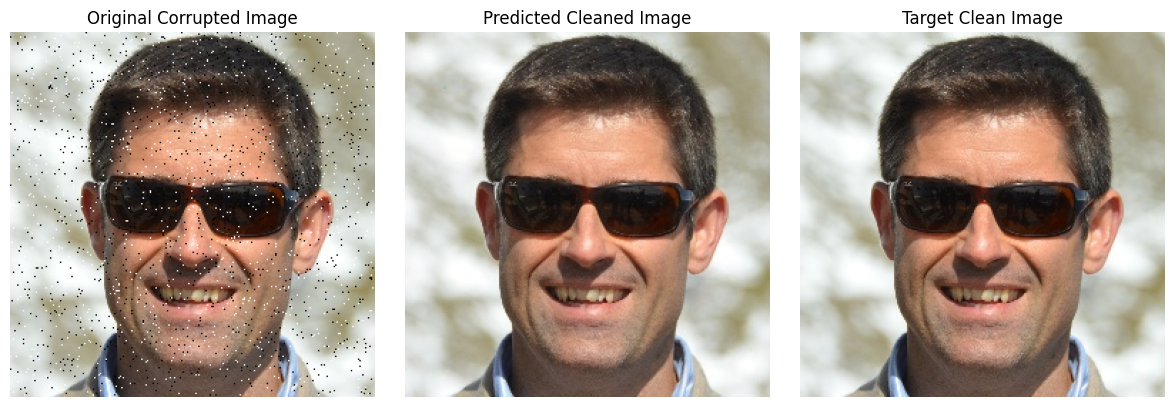

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0010416955..1.0323445].


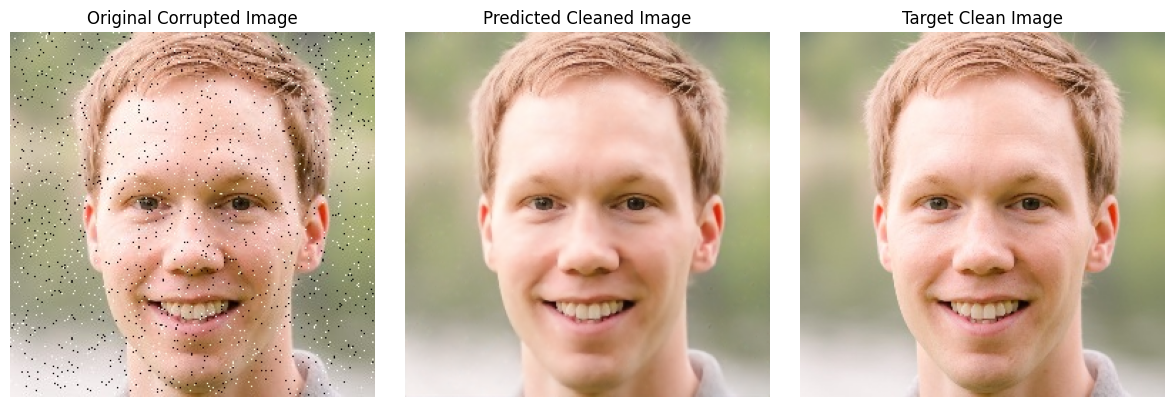

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03532137..0.95835].


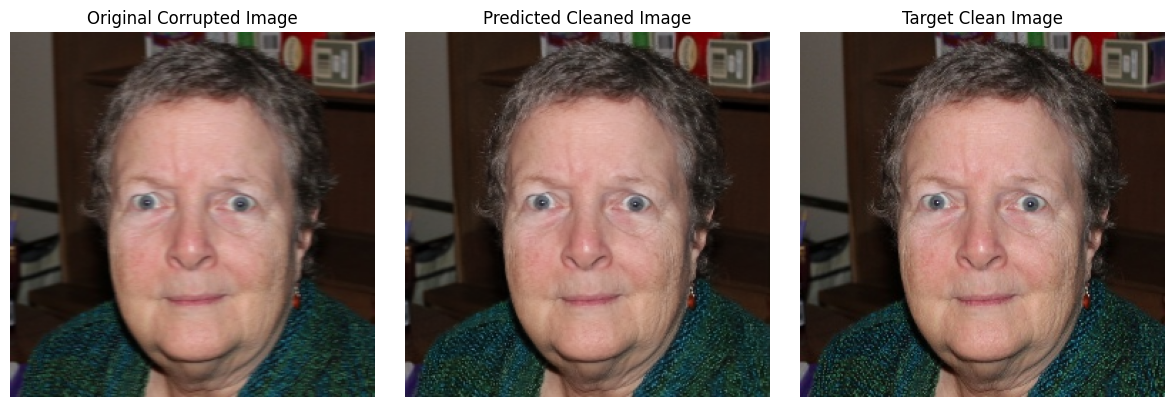

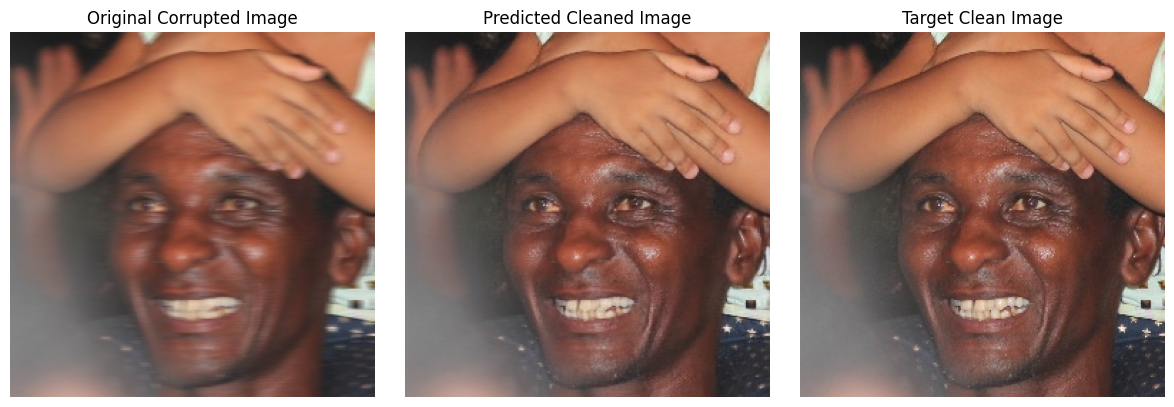

In [28]:
model_path = 'checkpoints/model_v1.pth' 
# model_path = 'checkpoints/model_epoch_6.pth' 
dataset_dir = './data/flickr/resized/train/img/' 
output_dir = './results/'  

# run inference and visualization
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)
run_inference_and_visualize(model_path, dataset_dir, output_dir)